In [17]:
from pinnsform import *
from pinnsform.model import PINN, FLS, FLW, FullWavelet, FLLWaveletRest, PINNsformer, PINNsformerNoAttention
from pinnsform.model import WaveAct
import matplotlib.pyplot as plt
import numpy as np

In [39]:
device = 'cuda'

def add_noise(model, noise=0.001):
    with torch.no_grad():
        for param in model.parameters():
            param.add_(torch.randn(param.size(), device=device) * 0.001)

def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.0)
    if isinstance(m, WaveAct):
        m.w1 = nn.Parameter(torch.ones(1, device=device), requires_grad=True)
        m.w2 = nn.Parameter(torch.ones(1, device=device), requires_grad=True)

In [40]:
problem_domain = ([0, 2*np.pi], [0, 1])
train_points = (51, 51)

In [41]:
np_mesh = generate_mesh(train_points, problem_domain)
np_sequence_mesh = make_temporal_sequence(np_mesh, num_step=5, step=1e-3)
np_mesh_sequence = listify_sequence(np_sequence_mesh)
mesh = torchify(np_mesh_sequence, device, True)

In [42]:
np_mesh = generate_mesh(train_points, problem_domain)
np_sequence_mesh = make_temporal_sequence(np_mesh, 5, 1e-3)
np_sequence_mesh = np.expand_dims(listify_sequence(np_sequence_mesh), 1)
single_sequence_mesh = torchify(np_sequence_mesh, device, True)

In [44]:
sequence_mesh, _ = generate_mesh_object(train_points, domain=problem_domain, device=device, full_requires_grad=True, border_requires_grad=False, num_seq_steps=5, seq_step_size=1e-3)

In [22]:
def calculate_temporal_correlation(model, mesh, seed = 0, repeats = 1000):
    print(seed)
    set_random_seed(seed)
    model.apply(init_weights)
    u_before = f(model, mesh).detach().cpu().numpy()
    u_after_list = []
    for j in range(repeats):
        set_random_seed(seed)
        model.apply(init_weights)
        set_random_seed(j+seed*repeats)
        add_noise(model, 0.001)
        u_after_list.append(f(model, mesh).detach().cpu().numpy())
    # calculate diffs
    diffs = []
    for u_after in u_after_list:
        diffs.append(u_after - u_before)
    diffs = np.reshape(np.array(diffs), (repeats, 51, 51*5))
    corr_matrices = [np.corrcoef(diffs[i].T) for i in range(repeats)]
    return np.mean(corr_matrices, axis=0)[0]

def mean_std_temp_corr(model, mesh, list_of_seeds, repeats):
    corr_matrices = [calculate_temporal_correlation(model, mesh, seed=i) for i in list_of_seeds]
    return np.mean(corr_matrices, axis=0), np.std(corr_matrices, axis=0), corr_matrices

In [23]:
NUM_SEEDS = 100
INIT_SEEDS = np.array(range(NUM_SEEDS))

In [71]:
pinnsformer_model = PINNsformer(d_out=1, d_hidden=512, d_model=32, N=1, heads=2).to(device)
pf_noatt_model = PINNsformerNoAttention(d_out=1, d_hidden=512, d_model=32, N=1, heads=2).to(device)
pinn_model = PINN(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)
pinn_deep_model = PINN(in_dim=2, hidden_dim=64, out_dim=1, num_layer=16).to(device)
fls_model = FLS(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)
flw_model = FLW(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)

In [25]:
mean, std, corr_list = mean_std_temp_corr(pinnsformer_model, sequence_mesh, INIT_SEEDS, 1000)
pinnsformer_corr = {
    "mean" : mean,
    "std" : std,
    "corr_list" : corr_list
}

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [30]:
mean, std, corr_list = mean_std_temp_corr(pf_noatt_model, sequence_mesh, INIT_SEEDS, 1000)
pf_noatt_corr = {
    "mean" : mean,
    "std" : std,
    "corr_list" : corr_list
}

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [46]:
mean, std, corr_list = mean_std_temp_corr(pinnsformer_model, single_sequence_mesh, INIT_SEEDS, 1000)
pinnsformer_noseq_corr = {
    "mean" : mean,
    "std" : std,
    "corr_list" : corr_list
}

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [59]:
for value in pinnsformer_noseq_corr["mean"]:
    print(value)

1.0
0.9999985857080496
0.9999943446937235
0.999987278675519
0.9999773873318495
0.9994357986642484
0.9993780558207098
0.9993175221381247
0.999254170159565
0.9991880254402367
0.9977504667366999
0.9976370232082731
0.997520805268245
0.997401825337442
0.997280092747456
0.9949589431034093
0.9947906948308355
0.9946197098996631
0.9944460249252355
0.9942695994824191
0.9910813809437355
0.9908594104578192
0.9906347983881729
0.9904075596200903
0.9901776531573393
0.9861427449777939
0.9858685041383023
0.9855916119173436
0.9853121940930595
0.9850302391610534
0.9801730395361156
0.9798480753634711
0.9795207058245662
0.979190751604526
0.9788583714393093
0.9732075150111246
0.9728338167598521
0.9724577189912516
0.9720792708738749
0.9716983765003749
0.9652873431817636
0.9648670472676217
0.9644445867902033
0.9640198104435926
0.9635927774005855
0.9564609084901755
0.955996824149037
0.9555305285397556
0.9550621637715082
0.9545917550948705
0.9467855039829971
0.9462805134443606
0.9457737153402577
0.9452649812018

In [61]:
for value in pf_noatt_corr["mean"]:
    print(value)

1.0
0.9999999030655978
0.9999996134206157
0.9999991301928322
0.9999984544947533
0.9994046638463777
0.999400742240207
0.9993966314218484
0.9993923297897541
0.999387839049202
0.9976194598718817
0.9976118090324365
0.9976039402327254
0.9975958784482786
0.997587646677613
0.9946548254278454
0.994643482419178
0.9946319738610938
0.994620280110944
0.9946084037655332
0.9905334620030442
0.9905186359442854
0.9905035903615453
0.9904884014458146
0.9904730184479688
0.9852922657860147
0.9852741006359764
0.9852557805326405
0.9852373078253049
0.9852186495404317
0.9789816543884077
0.9789605033682942
0.9789392256112042
0.9789176734223455
0.9788960807372318
0.9716615370353027
0.9716376961587789
0.9716137273642835
0.971589529520727
0.971565229217514
0.9633973741234287
0.9633711450602697
0.9633447850136163
0.9633182630518036
0.9632915399876696
0.9542582663974383
0.9542299335449498
0.9542015261405916
0.9541729157523133
0.9541441822532515
0.9443146629341683
0.9442845923415035
0.9442543384391116
0.9442239748982

In [63]:
for value in pinnsformer_corr["mean"]:
    print(value)

1.0
0.9999999096343324
0.9999996393747539
0.9999991889024904
0.999998558020161
0.9992701662136513
0.9992659789441279
0.9992616093066069
0.9992570598064958
0.9992523276615926
0.9970841066849423
0.9970757807891257
0.9970672665603675
0.9970585854431441
0.9970497065280728
0.9934694159577327
0.9934570338892732
0.9934445132648116
0.9934317686468727
0.993418865124058
0.9884761350791156
0.988459885683404
0.9884434807127908
0.9884268610515875
0.9884100966816277
0.9821686624222717
0.9821487093251386
0.982128546970079
0.9821082271886218
0.9820877035566558
0.9746235577814139
0.9745999904595877
0.9745763265564337
0.9745524400662612
0.9745284027275836
0.9659293759890829
0.9659025213960581
0.9658755592745366
0.9658483660518652
0.9658209743553076
0.9561831029024229
0.9561531667002484
0.9561230682761956
0.9560927614697394
0.9560623802136838
0.9454862685383199
0.9454534701009082
0.9454204410290191
0.9453873568321418
0.9453540345634436
0.9339421278344262
0.9339066527078497
0.9338709646598236
0.9338352012

In [72]:
mean, std, corr_list = mean_std_temp_corr(pinn_deep_model, mesh, INIT_SEEDS, 1000)
pinn_deep_corr = {
    "mean" : mean,
    "std" : std,
    "corr_list" : corr_list
}

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [73]:
for value in pinn_deep_corr["mean"]:
    print(value)

1.0
0.9999982736646441
0.9999932219641469
0.999984814602854
0.9999730680492207
0.9993546665517411
0.999290031573899
0.9992225520711693
0.9991521389602529
0.9990789028417928
0.9975320907844514
0.9974124879097745
0.9972903055874679
0.9971656502349652
0.9970385000505118
0.994710365899101
0.9945470407409015
0.9943816621155903
0.9942142052744883
0.9940446052506432
0.9910410139406552
0.9908349554924623
0.990627001902436
0.9904170878171294
0.9902051426624969
0.9865578359796018
0.98631454255828
0.9860695888119128
0.9858230801445225
0.9855748085074987
0.9813787510343502
0.9811042415915746
0.9808288488164021
0.9805522196729843
0.9802747752991664
0.9756819210135933
0.9753848647137612
0.9750865218613601
0.974787061313766
0.9744863605911324
0.9695254677811863
0.9692066919714328
0.968886892293217
0.9685661644233667
0.9682443602174129
0.9629796559483715
0.9626435613463147
0.9623068109686783
0.961969361582497
0.9616310163092743
0.9561507189055583
0.9558050888460281
0.9554591646045032
0.955112621540815

In [174]:
def visualize_mesh(mesh, domain):
    #[0,np.pi*2,1,0]
    plt.figure(figsize=(4,3))
    domain_extend = [domain[1][0], domain[1][1], domain[0][0], domain[0][1]]
    plt.imshow(mesh, extent=domain_extend, aspect='auto')
    plt.xlabel('t')
    plt.ylabel('x')
    plt.title('diff u(x,t)')
    plt.colorbar()
    plt.tight_layout()
    #plt.savefig('./1dreaction_pinnsformer_pred.png')
    plt.show()

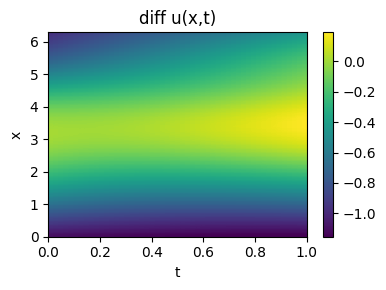

In [175]:
visualize_mesh(diffs_reshaped[0], problem_domain)

In [177]:
for value in np.mean(corr_matrices, axis=0)[0]:
    print(value)

1.0
0.999999848594347
0.9999993957600559
0.9999986392392658
0.9999975823651771
0.9998551145864611
0.9998457474958964
0.9998361106550038
0.9998261481656469
0.9998158859670861
0.999421283198778
0.9994027493132981
0.9993839767238327
0.9993648651386521
0.9993454672300904
0.9987008717438302
0.9986733116717466
0.9986454742213478
0.9986173205433048
0.9985888365657439
0.9976979603021605
0.9976614666533399
0.9976246897476817
0.9975876348395273
0.9975502259568371
0.9964180519160721
0.9963728494913017
0.9963273107084424
0.9962814862623118
0.9962354508977637
0.9948682443464348
0.9948144057086885
0.9947604324014433
0.994706053706983
0.994651468822348
0.9930567594317657
0.9929947781364504
0.9929324199484886
0.992869877764741
0.9928070752135634
0.9909934139180615
0.9909233267103444
0.9908531719088663
0.9907825522842293
0.9907117479870925
0.9886890194388797
0.9886113787180211
0.9885334169837293
0.988455351797938
0.9883769801036801
0.9861551868382307
0.9860703696420834
0.9859850898185708
0.985899733293

In [165]:
np.std(np.abs(corr_matrices), axis=0)[0]

array([0.00000000e+00, 1.18793864e-14, 1.85407245e-14, 9.10382880e-15,
       1.88737914e-14, 1.88737914e-14, 3.77475828e-15, 1.25455202e-14,
       1.08801856e-14, 1.74305015e-14, 5.10702591e-15, 1.21014310e-14,
       1.86517468e-14, 1.24344979e-14, 2.33146835e-14, 1.74305015e-14,
       1.93178806e-14, 1.42108547e-14, 1.55431223e-14, 1.79856130e-14,
       6.43929354e-15, 2.17603713e-14, 9.65894031e-15, 1.53210777e-14,
       4.88498131e-15, 3.44169138e-15, 1.12132525e-14, 8.43769499e-15,
       1.57651669e-14, 4.44089210e-15, 6.32827124e-15, 8.54871729e-15,
       1.73194792e-14, 1.22124533e-14, 1.17683641e-14, 8.32667268e-15,
       1.18793864e-14, 2.59792188e-14, 5.55111512e-15, 6.66133815e-15,
       1.53210777e-14, 1.52100554e-14, 1.70974346e-14, 1.44328993e-14,
       6.66133815e-15, 1.74305015e-14, 2.04281037e-14, 1.90958360e-14,
       1.80966353e-14, 7.43849426e-15, 1.72084569e-14, 1.87627691e-14,
       9.76996262e-15, 1.29896094e-14, 1.72084569e-14, 1.56541446e-14,
      